In this notebook, we will compute the percentage of forest cover in a particular MODIS pixel, given by a particular Lat/Lon.

In [2]:
import odc.stac
import odc.geo.geobox
import odc.geo.xr
import planetary_computer as pc
import pystac_client
import pystac
import pyproj
import stackstac
import rasterio
import rioxarray
import dask

import numpy as np
import pandas as pd
import xarray as xr
from scipy import linalg

from matplotlib import pyplot as plt
import leafmap

In [3]:
# In the MODIS pixel at this location, how much forest cover is there? Probably safe to interpolate
# from the nearest 4 pixels in case a location is at the corner.
lon, lat = -121.1403, 43.6479
buffer = 0.01

bbox = [lon - buffer, lat - buffer, lon + buffer, lat + buffer] # small square
date = "2020-01-01" # doesn't really matter

# Load the PC catalog
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,
)

In [5]:
modis = catalog.search(
    collections=["modis-11A2-061"],
    bbox=bbox,
    datetime="2020-01-01",
    query={"platform": {"eq": "aqua"}}
).get_all_items()

# Load MODIS first in its native projection to set the grid for the forest cover dataset
modis_data = odc.stac.load(
    modis,
    bbox=bbox,
    bands=["LST_Day_1km"]
).squeeze().drop_vars("time")

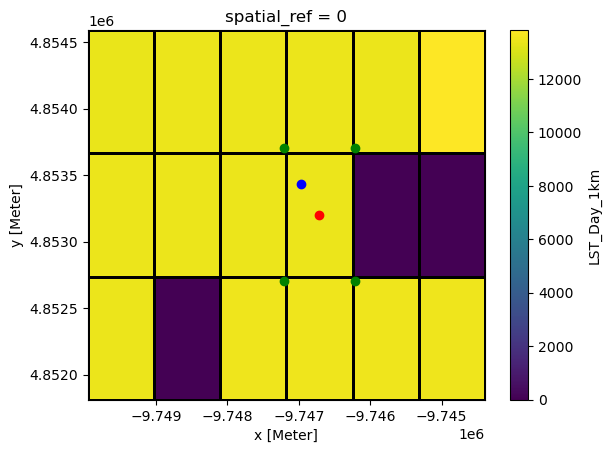

In [4]:
# Transform the desired point to MODIS projection and plot it, nearest pixel center
# and the bounds of that pixel.
modis_proj = '+proj=sinu +R=6371007.181 +nadgrids=@null +wktext'
latlon_to_modis_tform = pyproj.Transformer.from_crs("EPSG:4326", modis_proj, always_xy=True)
modis_to_latlon_tform = pyproj.Transformer.from_crs(modis_proj, "EPSG:4326", always_xy=True)

mod_x, mod_y = latlon_to_modis_tform.transform(lon, lat)

closest_x = modis_data.x.values[np.argmin(np.abs(mod_x - modis_data.x.values))]
closest_y = modis_data.y.values[np.argmin(np.abs(mod_y - modis_data.y.values))]

closest_px_bounds_x = [closest_x - 500, closest_x - 500, closest_x + 500, closest_x + 500]
closest_px_bounds_y = [closest_y - 500, closest_y + 500, closest_y - 500, closest_y + 500]

modis_data["LST_Day_1km"].plot.pcolormesh(edgecolors="k", linewidth=1)

plt.scatter([mod_x], [mod_y], color="blue")
plt.scatter([closest_x], [closest_y], color="red")
plt.scatter(closest_px_bounds_x, closest_px_bounds_y, color="green")

In [5]:
# Conver the nearest pixel bounds to latlon for extracting the forest cover data. I don't
# think there is a way to do an area extraction for the MODIS pixel, so we will just make a square
# and extract that. The data are fine enough that I don't think this will be a problem.
bounds_latlon_ll = modis_to_latlon_tform.transform(closest_x - 750, closest_y - 750)
bounds_latlon_ur = modis_to_latlon_tform.transform(closest_x + 750, closest_y + 750)

print(bounds_latlon_ll)
print(bounds_latlon_ur)

(-121.12859452528534, 43.639088428910114)
(-121.13715490168319, 43.65257823779401)


In [13]:
forest_bbox = [
    min(bounds_latlon_ll[0], bounds_latlon_ur[0]),
    min(bounds_latlon_ll[1], bounds_latlon_ur[1]),
    max(bounds_latlon_ll[0], bounds_latlon_ur[0]),
    max(bounds_latlon_ll[1], bounds_latlon_ur[1]),
]

forest = catalog.search(
    collections=["alos-fnf-mosaic"],
    datetime=date,
    bbox=forest_bbox
).get_all_items()

forest_data = odc.stac.load(
    forest,
    bands=["C"],
    bbox=forest_bbox
).squeeze().drop_vars("time")

In [ ]:
forest_data["is_forest"] = forest_data["C"] < 3
forest_data["is_forest"].mean().values

In [20]:
modis_proj = '+proj=sinu +R=6371007.181 +nadgrids=@null +wktext'
latlon_to_modis_tform = pyproj.Transformer.from_crs("EPSG:4326", modis_proj, always_xy=True)
modis_to_latlon_tform = pyproj.Transformer.from_crs(modis_proj, "EPSG:4326", always_xy=True)

def get_forest_cover_modis_grid(lat, lon):
    '''
    Get proportion of forest cover within a MODIS pixel at (lon, lat).
    '''
    buffer = 0.01

    bbox = [lon - buffer, lat - buffer, lon + buffer, lat + buffer] # small square
    date = "2020-01-01" # doesn't really matter

    # Get the MODIS grid in this location
    modis = catalog.search(
        collections=["modis-11A2-061"],
        bbox=bbox,
        datetime="2020-01-01",
        query={"platform": {"eq": "aqua"}}
    ).get_all_items()

    # Load MODIS first in its native projection to set the grid
    modis_data = odc.stac.load(
        modis,
        bbox=bbox,
        bands=["LST_Day_1km"]
    ).squeeze().drop_vars("time")
    
    mod_x, mod_y = latlon_to_modis_tform.transform(lon, lat)
    closest_x = modis_data.x.values[np.argmin(np.abs(mod_x - modis_data.x.values))]
    closest_y = modis_data.y.values[np.argmin(np.abs(mod_y - modis_data.y.values))]
    
    bounds_latlon_ll = modis_to_latlon_tform.transform(closest_x - 750, closest_y - 750)
    bounds_latlon_ur = modis_to_latlon_tform.transform(closest_x + 750, closest_y + 750)
    
    forest_bbox = [
        min(bounds_latlon_ll[0], bounds_latlon_ur[0]),
        min(bounds_latlon_ll[1], bounds_latlon_ur[1]),
        max(bounds_latlon_ll[0], bounds_latlon_ur[0]),
        max(bounds_latlon_ll[1], bounds_latlon_ur[1]),
    ]

    forest = catalog.search(
        collections=["alos-fnf-mosaic"],
        datetime=date,
        bbox=forest_bbox
    ).get_all_items()

    forest_data = odc.stac.load(
        forest,
        bands=["C"],
        bbox=forest_bbox
    ).squeeze().drop_vars("time")
    
    forest_data["is_forest"] = forest_data["C"] < 3
    return forest_data["is_forest"].mean().values

# Test
print(get_forest_cover_modis_grid(31, 8)) # Sahara desert
print(get_forest_cover_modis_grid(62, 112)) # Siberia
print(get_forest_cover_modis_grid(47.6577, -122.3067)) # UW
print(get_forest_cover_modis_grid(47.5069, -121.9744)) # Tiger Mountain

0.0
0.5490267751073746
0.03804017041996348
0.9379652605459057


In [22]:
sites = pd.read_csv("ameriflux_canopy_temp_site_locs.csv")

sites["forest_cover"] = sites.apply(
    lambda x: get_forest_cover_modis_grid(lat=x["LOCATION_LAT"], lon=x["LOCATION_LONG"]),
    axis=1
)

sites.head()

,SITE_ID,LOCATION_LAT,LOCATION_LONG,LOCATION_MODIS_X,LOCATION_MODIS_Y,forest_cover
0,CR-SoC,10.3827,-84.6210,-9.255366e+06,1.154505e+06,0.9996493688639552
1,PR-xGU,17.9696,-66.8687,-7.072769e+06,1.998131e+06,0.9988198269079465
2,PR-xLA,18.0212,-67.0769,-7.092715e+06,2.003868e+06,0.009984639016897081
3,US-GLE,41.3665,-106.2399,-8.865892e+06,4.599750e+06,0.8149405772495756
4,US-HWB,40.8608,-77.8488,-6.546847e+06,4.543519e+06,0.2129032258064516


<AxesSubplot:>

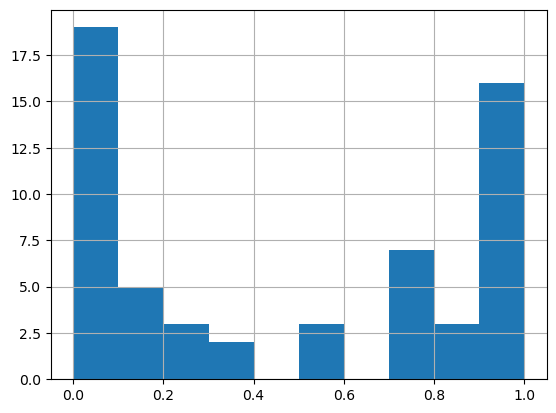

In [23]:
sites["forest_cover"].hist()

In [24]:
sites.to_csv("ameriflux_site_forest_cover.csv", index=False)